In [1]:
!pip install transformers torch torchvision pillow --quiet

In [2]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import requests
from io import BytesIO
import matplotlib.pyplot as plt

In [3]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

(np.float64(-0.5), np.float64(5055.5), np.float64(3416.5), np.float64(-0.5))

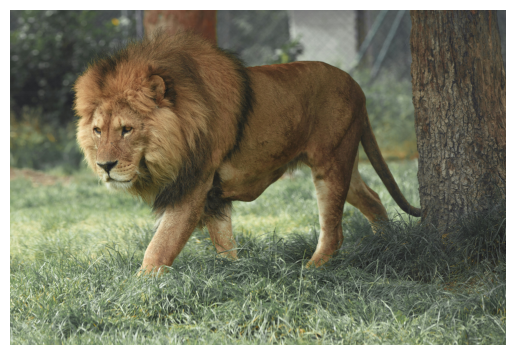

In [4]:
url = "https://images.unsplash.com/photo-1546182990-dffeafbe841d"
response = requests.get(url)
image = Image.open(BytesIO(response.content))

plt.imshow(image)
plt.axis("off")

In [5]:
captions = [
    "A dog running in the park",
    "A cat sitting on a sofa",
    "A group of people at a party",
    "A car on the road",
    "A person riding a bicycle",
    "A dog playing outdoors",
    "A pet in nature",
    "An animal running on grass"
]

In [6]:
inputs = processor(
    text=captions,
    images=image,
    return_tensors="pt",
    padding=True
)

outputs = model(**inputs)

logits_per_image = outputs.logits_per_image
probs = logits_per_image.softmax(dim=1)

In [7]:
best_idx = probs.argmax().item()
best_caption = captions[best_idx]

print("✅ Best Caption:", best_caption)

✅ Best Caption: An animal running on grass
